<a href="https://colab.research.google.com/github/jjyjung/ai_semicon/blob/main/src/dnn/tf_keras_DNN_SinCos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SinCos 데이터 생성**

image.png

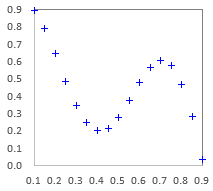

In [ ]:
import tensorflow as tf
import numpy as np
import math

def func(x):
    y = 0.5 * (math.cos(8*x) + math.sin(4*x) - x + 0.8)
    return y

## Training Data 생성
# numpy array 초기화
X_train = np.zeros(17)
y_train = np.zeros(17)

# 0.1에서 0.9까지 17개 훈련 데이터 생성
for i in range(17):
    x = 0.1 + i*0.05
    x = round(x, 2)
    y = func(x)
    X_train[i] = x
    y_train[i] = y

print("X_train", X_train)
print("y_train", y_train)

## Test Data 생성
# numpy array 초기화
X_test = np.zeros(81)
y_test = np.zeros(81)

# 0.1에서 0.9까지 81개 테스트 데이터 생성
for i in range(81):
    x = 0.1 + i*0.01
    x = round(x, 2)
    y = func(x)
    X_test[i] = x
    y_test[i] = y

print("X_test", X_test)
print("y_test", y_test)

X_train [0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65 0.7  0.75
 0.8  0.85 0.9 ]
y_train [0.89306253 0.78850011 0.64407828 0.48766207 0.34732269 0.24661369
 0.20063941 0.21354461 0.2778269  0.37558177 0.48148108 0.56700902
 0.60527701 0.57564515 0.46740539 0.28192819 0.03291544]
X_test [0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23
 0.24 0.25 0.26 0.27 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37
 0.38 0.39 0.4  0.41 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51
 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65
 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79
 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]
y_test [0.89306253 0.8765453  0.85764958 0.8365502  0.81343432 0.78850011
 0.76195533 0.73401584 0.70490419 0.67484797 0.64407828 0.61282818
 0.58133102 0.54981887 0.51852096 0.48766207 0.45746106 0.42812933
 0.39986942 0.37287361 0.34732269 0.32338463 0.30121354 0.2809486
 0.26271312 

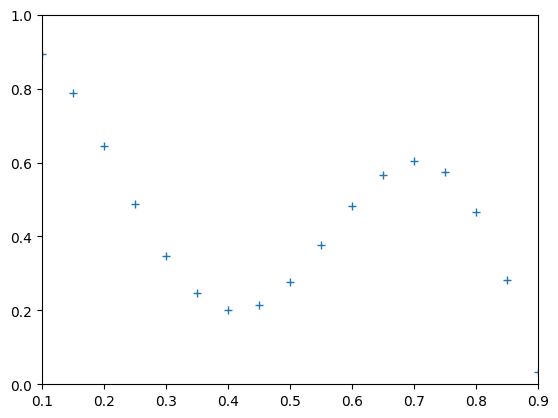

In [ ]:
import matplotlib.pyplot as plt

# 훈련 데이터 분포
plt.plot(X_train, y_train, '+')
plt.xlim([0.1, 0.9])
plt.ylim([0, 1.])
plt.show()

In [ ]:
import os
import random

# 실험결과 일관성을 위하여, 모든 random seed를 고정
def set_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(0)

In [ ]:
from tensorflow.keras import Sequential  # 모듈(변수나 함수를 포함)만 불러오기
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import RandomUniform

# -0.5에서 +0.5 사이로 초기화
initializer = RandomUniform(minval=-0.5, maxval=0.5)

# # 모델 구조 정의하기
# model = Sequential()                  # 순차적 계층 준비
# model.add(Dense(6, input_dim=1,       # 은닉노드 6개, 입력값 1차원
#                 activation='sigmoid', # 전통적 MLP의 Sigmoid 활성함수
#                 kernel_initializer=initializer))  # 전통적 MLP의 가중치 초기화 예시
# model.add(Dense(1, activation='linear')), # regression 문제는 선형활성함수 사용

# 모델 구조 정의하기
model = Sequential([
    Input(shape=(1,)),
    Dense(6, activation='sigmoid', kernel_initializer=initializer),
    Dense(3, activation='sigmoid', kernel_initializer=initializer),
    Dense(1, activation='linear'),
])

rmse = tf.keras.metrics.RootMeanSquaredError(name='rmse')
model.compile(
    loss='mse',
    optimizer=Adam(learning_rate=0.01),
    metrics=[rmse, 'mae', 'mape'],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37 (148.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.utils import shuffle

# 데이터 훈련하기
k = 2000
X_train, y_train = shuffle(X_train, y_train, random_state=0)

#'val_loss'를 monitor하여 감소하면 더 참고 조기중지
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

hist = model.fit(
    X_train, y_train,
    batch_size=100,     # 100개에 한 번씩 업데이터 실행
    epochs=k,           # 훈련 데이터셋을 총 60회 반복 실험. 단, 조기중지될 수 있음
    validation_split=0.2,
        #validation data 분할 비율. 즉, 15000개 중에서 10%인 1500개를 validation용으로 분할
    callbacks=[early_stopping],
    verbose=1)   # 전 과정을 화면에 출력(1) 또는 미출력(0) 모드

# 테스트 데이터로 평가하기
score = model.evaluate(X_test, y_test)
print('test_loss:', round(score[0], 6))
print('test_rmse:', round(score[1], 6))
print('test_mae:', round(score[2], 6))
print('test_mape:', round(score[3], 6))

Epoch 1/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 1.7868 - mae: 1.3220 - mape: 528.9218 - rmse: 1.3367 - val_loss: 1.9333 - val_mae: 1.3654 - val_mape: 322.7257 - val_rmse: 1.3904
Epoch 2/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 1.6740 - mae: 1.2786 - mape: 508.2936 - rmse: 1.2938 - val_loss: 1.8187 - val_mae: 1.3228 - val_mape: 311.6693 - val_rmse: 1.3486
Epoch 3/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 1.5669 - mae: 1.2360 - mape: 488.0197 - rmse: 1.2517 - val_loss: 1.7098 - val_mae: 1.2809 - val_mape: 300.8180 - val_rmse: 1.3076
Epoch 4/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 1.4652 - mae: 1.1942 - mape: 468.1242 - rmse: 1.2105 - val_loss: 1.6065 - val_mae: 1.2399 - val_mape: 290.1831 - val_rmse: 1.2675
Epoch 5/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 1.3690 - mae: 1.1532 - mape: 448.6274 - rmse: 1.1700 - val_loss: 1.5086 - val_mae: 1.1998 - val_mape: 279.7729 - val_rmse: 1.2283
Epoch 6/2000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - 

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[np.float32(0.58113116), np.float32(0.57627714), np.float32(0.5713743), np.float32(0.5664288), np.float32(0.561447), np.float32(0.5564356), np.float32(0.551401), np.float32(0.54635006), np.float32(0.5412891), np.float32(0.53622496), np.float32(0.531164), np.float32(0.5261124), np.float32(0.5210763), np.float32(0.51606166), np.float32(0.51107407), np.float32(0.506119), np.float32(0.50120133), np.float32(0.4963259), np.float32(0.49149716), np.float32(0.48671913), np.float32(0.4819955), np.float32(0.4773297), np.float32(0.47272488), np.float32(0.4681836), np.float32(0.4637083), np.float32(0.4593011), np.float32(0.45496368), np.float32(0.45069763), np.float32(0.44650397), np.float32(0.44238377), np.float32(0.43833748), np.float32(0.43436578), np.float32(0.4304688), np.float32(0.42664665), np.float32(0.42289916), np.float32(0.41922605), np.float32(0.41562682), np.float32(0.41210103), np.float32(0.40864784), np.float32(0.40526652), np.float32(0.40195626)

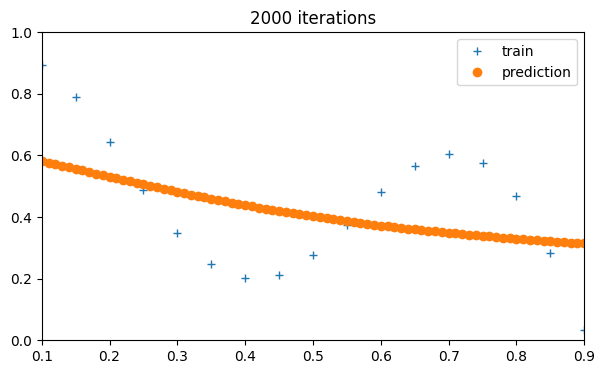

In [ ]:
import matplotlib.pyplot as plt

def draw_graph(x_train, y_train, x_test, y_pred, k):
    plt.figure(figsize=(7, 4))
    plt.plot(x_train, y_train, '+', label='train')
    plt.plot(x_test, y_pred, 'o', label='prediction')
    plt.legend(loc='upper right')
    plt.title(f'{k} iterations')
    plt.xlim([0.1, 0.9])
    plt.ylim([0, 1.0])
    plt.show()

y_pred = model.predict(X_test)
print(list(y_pred[:,0]))
draw_graph(X_train, y_train, X_test, y_pred, k)

In [ ]:
print(hist.history.keys())

dict_keys(['loss', 'mae', 'mape', 'rmse', 'val_loss', 'val_mae', 'val_mape', 'val_rmse'])


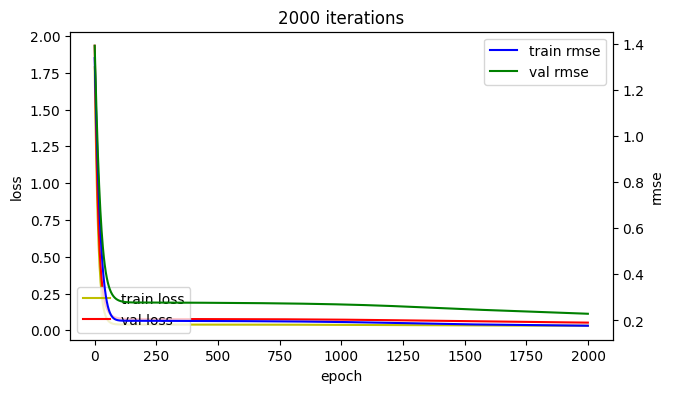

In [ ]:
def loss_graph(history, k):
    fig, loss_ax = plt.subplots(figsize=(7, 4))
    rmse_ax = loss_ax.twinx()

    loss_ax.plot(history.history['loss'], 'y', label='train loss')
    loss_ax.plot(history.history['val_loss'], 'r', label='val loss')
    rmse_ax.plot(history.history['rmse'], 'b', label='train rmse')
    rmse_ax.plot(history.history['val_rmse'], 'g', label='val rmse')

    loss_ax.set_xlabel('epoch')
    loss_ax.set_ylabel('loss')
    rmse_ax.set_ylabel('rmse')
    loss_ax.legend(loc='lower left')
    rmse_ax.legend(loc='upper right')
    plt.title(f'{k} iterations')
    plt.show()

loss_graph(hist, k)

Epoch 1/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.0419 - mae: 0.1880 - mape: 109.9041 - rmse: 0.2046 - val_loss: 0.0185 - val_mae: 0.1066 - val_mape: 21.6716 - val_rmse: 0.1359
Epoch 2/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0418 - mae: 0.1879 - mape: 110.1295 - rmse: 0.2045 - val_loss: 0.0184 - val_mae: 0.1074 - val_mape: 21.9248 - val_rmse: 0.1358
Epoch 3/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - loss: 0.0418 - mae: 0.1878 - mape: 110.5528 - rmse: 0.2044 - val_loss: 0.0184 - val_mae: 0.1083 - val_mape: 22.2746 - val_rmse: 0.1358
Epoch 4/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0417 - mae: 0.1877 - mape: 111.1385 - rmse: 0.2042 - val_loss: 0.0184 - val_mae: 0.1095 - val_mape: 22.6981 - val_rmse: 0.1357
Epoch 5/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - loss: 0.0416 - mae: 0.1875 - mape: 111.8483 - rmse: 0.2040 - val_loss: 0.0184 - val_mae: 0.1108 - val_mape: 23.1720 - val_rmse: 0.1358
Epoch 6/5000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - l

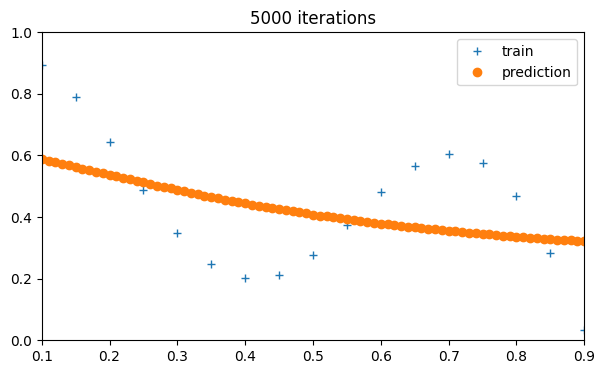

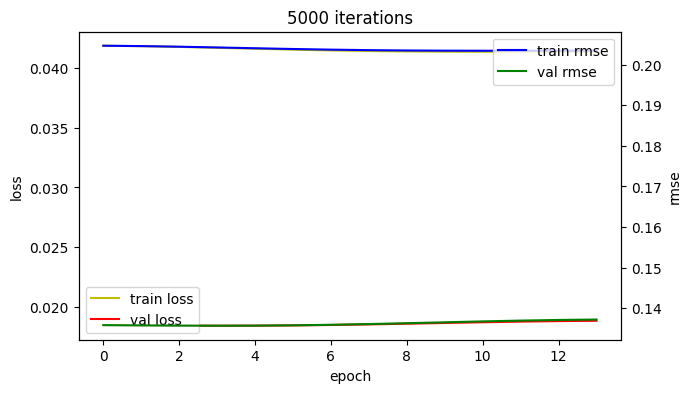

In [ ]:
from sklearn.utils import shuffle

def train_model(k=5000, save_path='dnn_sincos.keras'):
    x_train, y_train = shuffle(X_train, y_train_global, random_state=0)

    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
    )

    history = model.fit(
        x_train,
        y_train,
        batch_size=100,
        epochs=k,
        validation_split=0.2,
        callbacks=[early_stopping],
        verbose=1,
    )

    score = model.evaluate(X_test, y_test_global, verbose=0)
    print('test_loss:', round(score[0], 6))
    print('test_rmse:', round(score[1], 6))
    print('test_mae:', round(score[2], 6))
    print('test_mape:', round(score[3], 6))

    model.save(save_path)
    y_pred = model.predict(X_test, verbose=0).ravel()
    return model, history, score, y_pred

y_train_global = y_train
y_test_global = y_test

k = 5000
model, hist, score, y_pred = train_model(k)
print(list(y_pred))
draw_graph(X_train, y_train, X_test, y_pred, k)
loss_graph(hist, k)

In [ ]:
model.get_weights()

[array([[-5.929154  , -1.8014451 ,  0.15223214, -3.9291003 , -2.2949655 ,
         -3.1113675 ]], dtype=float32),
 array([ 0.37097523,  0.16901226, -0.1533337 , -0.0909413 ,  0.13165869,
        -0.19292893], dtype=float32),
 array([[-0.64660764, -1.0729283 , -0.37052336],
        [-0.78923   , -0.5239813 , -0.7798948 ],
        [-0.22424814,  0.34622878, -0.23095103],
        [-0.62149006, -0.49668282, -0.5671499 ],
        [-0.41732106, -0.4979882 , -0.8478246 ],
        [-0.36628997, -0.71417725, -0.1323136 ]], dtype=float32),
 array([-0.23527966, -0.15429084, -0.30794972], dtype=float32),
 array([[-0.27432957],
        [-0.6527854 ],
        [-0.27644023]], dtype=float32),
 array([0.80496055], dtype=float32)]

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113 (456.00 B)

 Trainable params: 37 (148.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 76 (308.00 B)